# Automated News Report Generator



## Problem

This notebook is the first stage of an automated pipeline that scrapes, summarizes and publishes a daily PDF report of the most relevant Spanish news. It's a portfolio project built to practice web scraping, data engineering and orchestration and MLOps tooling (Prefect, Docker, GitHub Actions, Hugging Face Spaces). It is strictly non-commercial: it is not monetized in any way, and no revenue or commercial benefit of any kind is planned from it, now or in the future.

## Data source and credit

All news content used in this notebook is sourced from **RTVE (Radiotelevisión Española)**, the Spanish public broadcaster, through the public news sitemap published at rtve.es. All rights over the original articles belong to RTVE. This notebook stores the full article text only for internal use; the full text is never redistributed publicly. Every news item in the final report links back to the original RTVE article as the source of record.

**For verified and complete information, always refer to RTVE directly** (rtve.es). This project produces short, automated summaries; they are not a substitute for the original reporting.

## What this notebook does

1. Downloads RTVE's Google News sitemap with a self-identifying User-Agent (not the classic RSS feed, see the design decision below).
2. Parses the XML and keeps only news published in the last `hours_limit` hours (configurable, default 48).
3. Extracts id, section, title and publication date for each article.
4. Stores everything in a local SQLite database (`news.db`), designed to be idempotent (safe to re-run without duplicating rows).
5. Scrapes the full body, short description and topic category of each article with Playwright and updates the database.
6. Selects the `number_of_news` most recent general-news articles (`Section = 'noticias'`, configurable count, default 10), optionally filtered further by a specific `Category` (e.g. "Economía") if one is given.
7. Summarizes each selected article in Spanish with a local LLM (`Qwen/Qwen2.5-1.5B-Instruct`), running fully offline on CPU.
8. Builds a daily PDF report with ReportLab: a cover page followed by each news item's title, category, AI-generated summary, and a citation (source + link to the original RTVE article).

`hours_limit`, `number_of_news` and `category` are all plain variables in this notebook for now, meant to be exposed later as user-facing inputs (sliders / a category dropdown) in an interactive dashboard.

## Key design decision (verified, not assumed)

The original plan was to use RTVE's classic RSS feed via `feedparser`. Checking RTVE's actual `robots.txt` showed that the classic feed redirects to `api2.rtve.es`, a host that is both stale (last updated in 2022) and blocked by its own `robots.txt`. Instead, this notebook uses RTVE's **Google News sitemap** (`https://www.rtve.es/sitemaps/sitemaps-news.xml`), which is explicitly allowed (`Allow: /sitemaps/*.xml$`), live, and links directly to each article page.

## Legal note

`robots.txt` only grants technical crawling permission, it says nothing about usage rights over the content. RTVE's legal notice prohibits reproducing its content without authorization. That's why the full article body (`Body`) is stored only for internal use and is never published as-is in the final PDF or dashboard. What gets published downstream is only the title, category, an AI-generated summary, the source (RTVE), and a link to the original article. The citation (source + link) is always attached in code from the database, never left for the model to write from memory, so it can't be dropped or hallucinated.


In [1]:
# Data analysis libraries (inherited from the project template)
import pandas as pd
import numpy as np
import random

# HTTP download of the sitemap
import requests

# Parsing the sitemap XML (sitemap.org + Google News namespaces)
import xml.etree.ElementTree as ET

# Dates: recency filtering and pipeline timestamps
from datetime import timezone, datetime, timedelta

# Persistence for the extracted news
import sqlite3

# Scraping the article body. Using the ASYNC API (async_api) because
# Jupyter already runs its own asyncio event loop, and Playwright's
# sync API (sync_playwright) is incompatible with that inside a notebook
# (it works fine in a plain terminal script, just not here).
import playwright
from playwright.async_api import async_playwright

# Local LLM for summarization: tokenizer + causal language model, run on CPU.
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

# PDF report generation with ReportLab's high-level "Platypus" API:
# a list of flowables (Paragraph, Spacer, PageBreak) gets laid out and
# paginated automatically by SimpleDocTemplate, no manual coordinates needed.
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, PageBreak
import pymupdf
from IPython.display import Image
import json

/home/alejandro/Escritorio/Proyectos portafolio/Automated News Report Generator/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

SEED = 123
np.random.seed(SEED)
random.seed(SEED)

## 1. Downloading the news sitemap

The sitemap is downloaded with `requests`, sending a **self-identifying User-Agent** (`AutomatedNewsReportBot/1.0`) instead of Python's default one.

This isn't cosmetic: checking RTVE's `robots.txt` showed it explicitly blocks `User-Agent: Python-urllib` (the default used by `feedparser`/`urllib`) with `Disallow: /` for the entire site. Identifying with a proper User-Agent is also good scraping etiquette: anyone reviewing RTVE's server logs can tell what this bot is and how to reach out.


In [3]:
# GET request with a custom User-Agent (see markdown cell above for why).
# 200 = OK, request went through without being blocked.
x = requests.get('https://www.rtve.es/sitemaps/sitemaps-news.xml', headers={"User-Agent":"AutomatedNewsReportBot/1.0 (https://github.com/AlejandroBeldaFernandez/Automated-News-Report)"})
print(x.status_code)

200


In [4]:
# Peek at the raw XML to locate the namespace declarations (xmlns) before
# trying to query the tree with ElementTree.
print(x.text[:500])

<?xml version="1.0" encoding="UTF-8" standalone="yes"?>
<urlset xmlns="http://www.sitemaps.org/schemas/sitemap/0.9" xmlns:news="http://www.google.com/schemas/sitemap-news/0.9" xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" xsi:schemaLocation="http://www.sitemaps.org/schemas/sitemap/0.9 http://www.sitemaps.org/schemas/sitemap/0.9/sitemap.xsd http://www.google.com/schemas/sitemap-news/0.9 http://www.google.com/schemas/sitemap-news/0.9/sitemap-news.xsd">
  <url>
    <loc>https://www.rtve.es/


In [5]:
# XML namespace map. ElementTree needs this to resolve tags like
# "sitemaps:url" or "labels:title" to their full {uri}tag form internally.
# "sitemaps" -> the standard sitemap.org namespace (url, loc)
# "labels"   -> the Google News extension namespace (news, title, publication_date)
dicc = {"sitemaps": "http://www.sitemaps.org/schemas/sitemap/0.9", "labels": "http://www.google.com/schemas/sitemap-news/0.9"}

In [6]:
# Parse the XML text into a navigable tree. `root` is the <urlset> element.
# Note the tags print with the namespace URI prefixed in {curly braces},
# which is exactly why the namespace map above is needed for any find/findall.
root = ET.fromstring(x.text)
print(root.tag)
print(root[0].tag)

{http://www.sitemaps.org/schemas/sitemap/0.9}urlset
{http://www.sitemaps.org/schemas/sitemap/0.9}url


In [7]:
# All <url> entries in the sitemap: one per news item.
urls = root.findall('sitemaps:url', dicc)


### Trying field extraction on a single entry

Before looping over all entries, extract `loc`, `news:title` and `news:publication_date` from the first item to confirm the namespace paths are correct.


In [8]:
# The article URL for the first entry.
urls[0].find("sitemaps:loc", dicc).text


'https://www.rtve.es/catalunya/noticies/20260820/l1-metro-florida-placa-sants-reobrira-29-agost/17196748.shtml'

In [9]:
# "news:title" is nested inside "news:news", so the path has to go through
# that intermediate element first.
urls[0].find("labels:news/labels:title", dicc).text

"El tram de l'L1 del metro tancat entre Florida i plaça de Sants reobrirà el 29 d'agost"

In [10]:
# ISO 8601 timestamp with timezone offset, needed later for the recency filter.
urls[0].find("labels:news/labels:publication_date", dicc).text


'2026-08-20T13:31:52+02:00'

## 2. Building the news list: parsing, recency filter and field extraction

For every entry in the sitemap:
- Parse `loc`, `news:title` and `news:publication_date`.
- **Recency filter**: RTVE's sitemap is *not* limited to the last 48 hours as Google News sitemaps typically are (verified live: it mixed articles from 2008 with today's). So the 48h cutoff is enforced here in the pipeline, not assumed from the source.
- **`section`** and **`rtve_id`**: derived from the URL itself, since the sitemap doesn't provide them as separate fields. `rtve_id` extraction is defensive: if the last path segment isn't purely numeric, it's set to `None` and logged instead of crashing the whole loop, since this is external data RTVE could change.
- **`discovered_at`**: timestamp of this extraction, used later as the "phase 1" insertion time in SQLite.


In [11]:
news = []
# Configurable recency window in hours, meant to eventually come from a
# user-facing input (e.g. an "hours or days" selector in a dashboard).
hours_limit = 48
for item in urls:
    url = item.find("sitemaps:loc", dicc).text
    title = item.find("labels:news/labels:title", dicc).text
    published_at = item.find("labels:news/labels:publication_date", dicc).text
    publishet_at_correct = datetime.fromisoformat(published_at)
    actual_date = datetime.now(timezone.utc)

    # Recency filter: skip anything older than hours_limit (see markdown above,
    # the sitemap itself is not pre-filtered by RTVE).
    if (actual_date -  publishet_at_correct) > timedelta(hours=hours_limit):
        continue

    # section (e.g. "noticias", "deportes") is the 4th path segment.
    url_splitted = url.split("/")
    section = url_splitted[3]

    # rtve_id is the numeric id at the end of the URL, before ".shtml".
    # Defensive: don't crash on a URL that doesn't follow this pattern,
    # just flag it and store None.
    rtve_id = url_splitted[-1].split(".")[0]
    if rtve_id.isdigit():
        rtve_id = int(rtve_id)
    else:
        rtve_id = None
        print("Not Id in url: ", url)

    element = {"url": url, "title": title, "published_at": published_at, "section": section, "rtve_id": rtve_id, "discovered_at": actual_date.isoformat()}
    news.append(element)


## 3. Persisting to SQLite

Schema decisions, closed before writing any code:

- **`Url` is the `PRIMARY KEY`**, not `Rtve_id`. The URL (`loc`) is the only field the sitemap protocol always guarantees present and unique; the numeric id is something *we* derive from it and that extraction can fail, so it can't be a non-null primary key.
- **Two-phase schema**: `Body`, `Short_Description` and `Scrapped_at` are nullable because they only get filled later by Playwright (phase 2). Everything else is `NOT NULL` because it comes straight from the sitemap.
- **Idempotency**: `CREATE TABLE IF NOT EXISTS` + `INSERT OR IGNORE` so the whole notebook can be re-run (e.g. tomorrow, or after a retry in the future Prefect pipeline) without crashing or duplicating rows. This also doubles as the deduplication mechanism.


In [12]:
# Connects to (or creates) a real database FILE, not an in-memory one,
# so the data persists across notebook runs.
conn = sqlite3.connect("news.db")
cur = conn.cursor()


In [13]:
# IF NOT EXISTS: safe to re-run without erroring if the table is already there.
# Category added as an 11th column, NOT NULL DEFAULT 'News': it's filled in
# phase 2 like Body/Short_Description, but unlike those, a plain default
# string is used instead of NULL so it always has a sensible value even if
# scraping that one article's category fails.
cur.execute("CREATE TABLE IF NOT EXISTS News (Url varchar(255) PRIMARY KEY NOT NULL, Rtve_id INTEGER , Title varchar(255) NOT NULL, Section varchar(255), Published_at varchar(255) NOT NULL, Discovered_at varchar(255) NOT NULL, Body varchar(255), Short_Description varchar(255), Scrapped_at varchar(255), Source varchar(255) NOT NULL DEFAULT 'RTVE',  Category varchar(255) NOT NULL DEFAULT 'News')")

In [14]:
# Build one tuple per news item, values in the exact column order of the
# News table (now 11 columns). Body/Short_Description/Scrapped_at are None
# here (phase 1), and Category defaults to 'News' here too, since the real
# category also only gets filled in the Playwright step further down (phase 2).
tuples = []
for new in news:
    tuples.append((new['url'], new['rtve_id'], new['title'], new['section'], new['published_at'], new['discovered_at'], None, None, None, 'RTVE', 'News'))

In [15]:
# OR IGNORE: if a row with this Url already exists (PRIMARY KEY clash),
# silently skip it instead of raising an IntegrityError. This is the
# deduplication mechanism decided for this pipeline.
# 11 placeholders, one per column (10 would raise "table News has 11
# columns but 10 values were supplied", verified when Category was added).
cur.executemany("INSERT OR IGNORE INTO News VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)", tuples)

In [16]:
# Commit once at the end of phase 1, not once per row.
conn.commit()

## 4. Scraping the article body with Playwright (single-article test)

Selectors verified by inspecting a real RTVE article page's HTML, not guessed:
- Article body: `.artBody` (a `<div class="artBody">` inside `.mainContent`).
- Short description: the `content` attribute of `<meta name="description">`.
- Topic category: the `data-category` attribute of the same `<article class="mark article">` tag that holds the body, a JSON string like `{"id":"1011","parent":"TE_NOTICI","name":"Economía"}`. Verified live against a real economy article: `data-category` gave `"name": "Economía"` exactly. This is what makes filtering by fine-grained topic (economy, culture, a specific region...) possible, unlike `Section`, which only distinguishes `noticias` from `deportes`/`play`/`catalunya`/`rtve` at the URL level and lumps every other topic together under `noticias`.

Playwright's browser identifies itself as a normal Chrome browser by default, which is intentionally kept as-is (not overridden with the custom bot User-Agent used for the sitemap download). RTVE's `robots.txt` is served from an `/akamai/` path, a sign that a bot-management WAF sits in front of the site; a realistic browser User-Agent is less likely to be fingerprinted and blocked on pages meant for human visitors.

Tested here on a single article (`news[0]`) before running the full loop over every item.


In [17]:
# NOTE: uses the ASYNC Playwright API (async with / await) because Jupyter
# already runs its own asyncio event loop; sync_playwright would raise
# "Sync API inside the asyncio loop" here (it's fine in a plain .py script).
async with async_playwright() as p:
    browser = await p.chromium.launch()
    page = await browser.new_page()
    await page.goto(news[0]["url"])
    body = await page.inner_text(".artBody")
    short_description = await page.get_attribute('meta[name="description"]', 'content')
    # data-category is a JSON string; parse it and keep only the "name" field.
    category_json = await page.get_attribute("article.mark.article", "data-category")
    category = json.loads(category_json)["name"]

    print(await page.title())
    await browser.close()

L'L1 del Metro reobre Florida-Plaça de Sants el 29 d'agost


## 5. Full scraping loop and final persistence

Loops over every item in `news`, scrapes body + short description + category, and runs an `UPDATE` on the matching row (`WHERE Url = ?`) to fill in the phase-2 columns.

Design notes:
- The `browser` is launched **once** and reused for all articles (expensive to start), but a fresh `page` is opened and closed per article (cheap, avoids accumulating tabs).
- The `try/except` around the scraping call is the same defensive philosophy applied earlier to `rtve_id`: if one article's page fails to load or its HTML doesn't match the expected selectors, that single row just ends up with `Body`/`Short_Description` as `None` and `Category` as `'News'` (the schema default), the loop keeps going instead of crashing for the other ~75 articles. Verified against a real run: one article timed out and correctly fell back to `Category = 'News'` while the other ~100 got their real category (Economía, Sociedad, Cultura, Ceuta, Rusia, and many more).
- Known gap, not yet fixed: `.artBody` also contains "related articles" boxes (`.incluBox`) interleaved with the real paragraphs, so `Body` currently includes that noise. Left as an open item for a future text-cleaning step.
- `conn.commit()` runs once after the loop, not per row.


In [18]:
async with async_playwright() as p:
    browser = await p.chromium.launch()

    for item in news:
        page = await browser.new_page()
        try:
            await page.goto(item["url"], timeout=30000)
            body = await page.inner_text(".artBody")
            short_description = await page.get_attribute('meta[name="description"]', "content")
            category_json = await page.get_attribute("article.mark.article", "data-category")
            category = json.loads(category_json)["name"]
        except Exception as e:
            # Defensive: one bad article must not stop the whole batch.
            # Category falls back to 'News' (the schema default), not None,
            # to match the NOT NULL constraint on that column.
            print("Fail in", item["url"], ":", e)
            body = None
            short_description = None
            category = 'News'
        await page.close()

        scraped_at = datetime.now(timezone.utc).isoformat()
        cur.execute(
            "UPDATE News SET Body = ?, Short_Description = ?, Scrapped_at = ?, Category = ? WHERE Url = ?",
            (body, short_description, scraped_at, category, item["url"])
        )

    await browser.close()

conn.commit()


Fail in https://www.rtve.es/play/noticias/20260820/hora-donde-ver-tv-campeonato-europa-gimnasia-artistica-masculina/17194449.shtml : Page.get_attribute: Timeout 30000ms exceeded.
Call log:
  - waiting for locator("article.mark.article")



Fail in https://www.rtve.es/play/noticias/20260820/150000-kilos-tomate-extremeno-tomatina-bunol/17194030.shtml : Page.get_attribute: Timeout 30000ms exceeded.
Call log:
  - waiting for locator("article.mark.article")



Fail in https://www.rtve.es/play/noticias/20260820/mensaje-body-positive-lalachus/17195783.shtml : Page.get_attribute: Timeout 30000ms exceeded.
Call log:
  - waiting for locator("article.mark.article")



Fail in https://www.rtve.es/play/noticias/20260820/maestros-costura-celebrity-finalistas/17195806.shtml : Page.get_attribute: Timeout 30000ms exceeded.
Call log:
  - waiting for locator("article.mark.article")



Fail in https://www.rtve.es/play/noticias/20260820/expulsion-dificil-maestros-costura-celebrity-quedado-puertas-gran-final/17195821.shtml : Page.get_attribute: Timeout 30000ms exceeded.
Call log:
  - waiting for locator("article.mark.article")



...

Fail in https://www.rtve.es/play/noticias/20260818/antes-tiktok-valerio-lazarov-zooms-cromas-espectaculo-viaje-centro-tele/17193549.shtml : Page.get_attribute: Timeout 30000ms exceeded.
Call log:
  - waiting for locator("article.mark.article")



Fail in https://www.rtve.es/play/noticias/20260818/por-granada-se-sufren-tantos-terremotos-jacob-petrus-da-explicacion/17195006.shtml : Page.get_attribute: Timeout 30000ms exceeded.
Call log:
  - waiting for locator("article.mark.article")



Fail in https://www.rtve.es/play/noticias/20260818/angela-exige-a-maximo-marcharse-promesa-antes-posible/17195055.shtml : Page.get_attribute: Timeout 30000ms exceeded.
Call log:
  - waiting for locator("article.mark.article")



Fail in https://www.rtve.es/play/noticias/20260818/vuelta-ciclista-2026-hora-donde-ver-gratis-todas-etapas/17194425.shtml : Page.get_attribute: Timeout 30000ms exceeded.
Call log:
  - waiting for locator("article.mark.article")



Fail in https://www.rtve.es/play/noticias/20260818/navarra-aceite-industrial-usado/17194373.shtml : Page.get_attribute: Timeout 30000ms exceeded.
Call log:
  - waiting for locator("article.mark.article")



## Results

Quick sanity check on what actually landed in `news.db`, run against the real database rather than assumed.


In [19]:
# Row counts and how many rows completed phase 2 (Playwright scraping).
cur.execute("SELECT COUNT(*), COUNT(Body), COUNT(Short_Description) FROM News")
total, with_body, with_short_description = cur.fetchone()
print(f"Total news rows: {total}")
print(f"Rows with Body scraped: {with_body}")
print(f"Rows with Short_Description scraped: {with_short_description}")

cur.execute("SELECT Section, COUNT(*) FROM News GROUP BY Section ORDER BY COUNT(*) DESC")
print("\nBy section:")
for section, count in cur.fetchall():
    print(f"  {section}: {count}")

Total news rows: 141
Rows with Body scraped: 124
Rows with Short_Description scraped: 124

By section:
  noticias: 94
  play: 17
  deportes: 12
  catalunya: 10
  rtve: 8


## 6. Selecting the most relevant news

Selection criterion for the daily report: only articles from the general `noticias` section (excludes `play`, `deportes`, `catalunya`, `rtve`), the `number_of_news` most recent by `Published_at` (configurable, default 10). If a `category` is given (one of the fine-grained values scraped in section 5, e.g. `"Economía"`), the selection is narrowed further to just that topic; if `category` is `None`, no extra filter is applied. Verified against real data: filtering by `category="Economía"` on a live-scraped database returned only genuine economy headlines (inflation, Ibex 35, rent prices...).


In [20]:
# fetchall() to get all number_of_news rows at once, not fetchone() (which
# would only return the first). `news` here shadows the earlier sitemap list
# on purpose, it's the same idea (a list of news items) at a later stage.
#
# category=None means "no extra filter": two versions of the query instead
# of one, because SQL placeholders (?) can only stand in for values, not for
# conditionally including/excluding a whole "AND Category = ?" clause.
number_of_news = 10
category = None
if category:
    cur.execute("SELECT Title, Body, Url, Short_Description, Published_at, Source, Category FROM News WHERE Section='noticias' AND Category= ?  ORDER BY Published_at DESC LIMIT ?", (category, number_of_news))
else: 
    cur.execute("SELECT Title, Body, Url, Short_Description, Published_at, Source, Category FROM News WHERE Section='noticias' ORDER BY Published_at DESC LIMIT ?", (number_of_news,))
news = cur.fetchall()


## 7. Summarization model

Model: `Qwen/Qwen2.5-1.5B-Instruct`, a small instruction-tuned LLM, run locally and fully offline (no external API, no per-request cost). No GPU is available on this machine, so it runs on CPU; at 1.5B parameters this is still practical for 10 articles.

Prompt design decisions:
- Only `title`, `body` and `short_description` are passed to the model. `url`, `published_at` and `source` are deliberately left out of the prompt: the model doesn't need them to summarize, and keeping them out avoids the model trying to comment on or reproduce them.
- The prompt explicitly forbids using outside knowledge ("no uses conocimiento externo ni supongas nada que no esté en las noticias"), to keep the summary grounded in the scraped article and reduce hallucination.
- Source and URL are **not** requested from the model. They are attached afterwards in plain code, taken directly from the database row, since that's guaranteed correct, whereas asking an LLM to reproduce a citation reliably is not. See `report_entry` below.
- A word limit is requested in the prompt (max 100 words) to keep summaries short; `max_new_tokens=800` is set generously as a hard safety cap, not as the target length, after an early test showed the summary getting cut off mid-sentence at `max_new_tokens=400`.


In [21]:
# Builds the prompt from just the three fields the model actually needs.
# "\n".join keeps title/body/short_description on separate lines so the
# model can tell where each field starts and ends.
def build_prompt(title, body, short_description):
    context = "\n".join([title, body, short_description])
    return f"""Eres un experto en resumir noticias. Genera un texto resumen acerca de las noticias que te pasamos sin incluir informacion externa

Reglas:
- No uses conocimiento externo ni supongas nada que no esté en las noticias.
- Responde en un maximo de 100 palabras


Noticia:
{context}


Respuesta:"""

In [22]:

# Loads once: tokenizer + model weights (already cached locally from an
# earlier try, ~2.9GB, no re-download needed). eval() disables dropout/etc,
# not needed for inference but is the correct mode for generation.
LLM = 'Qwen/Qwen2.5-1.5B-Instruct'
llm_tok = AutoTokenizer.from_pretrained(LLM)
llm = AutoModelForCausalLM.from_pretrained(LLM, torch_dtype=torch.float32)
llm.eval()

def answer(title, body, short_description):
    # Qwen is a chat/instruct model: apply_chat_template wraps the prompt
    # in the system/user/assistant format it was fine-tuned on.
    messages = [{'role': 'user', 'content': build_prompt(title, body, short_description)}]
    text = llm_tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = llm_tok(text, return_tensors='pt')

    # do_sample=False: greedy decoding, deterministic output for the same input.
    with torch.no_grad():
        out = llm.generate(**inputs, max_new_tokens=800, do_sample=False)

    # Slice off the input prompt tokens (inputs['input_ids'].shape[1]) before
    # decoding, otherwise the result includes the whole system/user/assistant
    # prompt text instead of just the model's new answer.
    return llm_tok.decode(out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)

# Single-article test before looping over all number_of_news items.
# The SELECT above now returns 7 columns: new[0]=Title, new[1]=Body,
# new[2]=Url, new[3]=Short_Description, new[4]=Published_at, new[-2]=Source,
# new[-1]=Category. source/url/category come straight from the row, not
# from the model (see markdown above).
new = news[0]
summary = answer(new[0], new[1], new[3])
report_entry = {"title": new[0], "summary": summary, "source": new[-2], "url": new[2],"category": new[-1]}

print(f"{report_entry["summary"]} \n Source: {report_entry["source"]} \n {report_entry["url"]}")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loading weights:   0%|          | 1/338 [00:00<01:46,  3.18it/s]

Loading weights:  40%|███▉      | 135/338 [00:00<00:00, 395.34it/s]

Loading weights:  59%|█████▉    | 201/338 [00:00<00:00, 375.04it/s]

Loading weights:  75%|███████▍  | 253/338 [00:00<00:00, 366.39it/s]

Loading weights:  88%|████████▊ | 298/338 [00:01<00:00, 262.27it/s]

Loading weights:  99%|█████████▊| 333/338 [00:01<00:00, 268.63it/s]

Loading weights: 100%|██████████| 338/338 [00:01<00:00, 284.02it/s]

Corea del Norte ha lanzado diez misiles balísticos próximos a la zona económica exclusiva de Japón, provocando una respuesta inmediata desde Corea del Sur. El Ejército surcoreano ha ordenado a sus tropas mantenerse preparadas para futuros enfrentamientos. La Casa Azul, encargada del gobierno surcoreano, ha pedido a Pyongyang que suspenda todas las acciones provocativas. Estados Unidos, que ha reducido sus ejercicios militares con Corea del Sur, ha criticado la acción norcoreana pero ha mantenido relaciones diplomáticas con Pyongyang. Corea del Norte ha utilizado el lanzamiento de misiles como una táctica política para mostrar su independencia y desafiar a otros países. 
 Source: RTVE 
 https://www.rtve.es/noticias/20260820/corea-norte-lanza-diez-misiles-balisticos-aguas-japonesas-corea-sur-exige-parar-provocacion/17196603.shtml


In [23]:
# Same call as the single-article test, now for all number_of_news selected
# items. One LLM call per article (not one combined call for all of them),
# so each report_entry gets its own independent summary, category and citation.
reports_entry = []
for new in news:
    summary = answer(new[0], new[1], new[3])
    report_entry = {"title": new[0], "summary": summary, "source": new[-2], "url": new[2],"category": new[-1]}
    reports_entry.append(report_entry)

## 8. Building the PDF report

Using ReportLab's high-level "Platypus" API instead of the low-level `Canvas` API: with 10 news items of variable summary length, manually calculating X/Y coordinates and page breaks would be unnecessary work. Platypus takes a list of flowables (`story`) and handles pagination automatically when `doc.build(story)` is called.


In [24]:
# The document object (not built yet, just configured) and the predefined
# paragraph styles (Title, Heading2, Normal...) used below.
doc = SimpleDocTemplate("report.pdf", pagesize=A4)
styles = getSampleStyleSheet()


In [25]:
# The cover page title, using the built-in "Title" style.
title = Paragraph("Report of RTVE news", styles["Title"])


In [26]:
# `story` is the full ordered list of everything that goes into the PDF.
# PageBreak() separates the cover page from the news items added next.
story = [title, Spacer(1, 20), PageBreak()]


In [27]:
# One block per news item: title, category, AI summary, and the citation.
# The citation is built here in plain Python from report_entry["source"]/["url"]
# (the database values), not from anything the model generated, so it's always
# correct. <a href="..."> makes the URL a clickable link in the PDF.
for report_entry in reports_entry:
    story.append(Paragraph(report_entry["title"], styles["Heading2"]))
    story.append(Paragraph(report_entry["category"], styles["Heading3"]))
    story.append(Paragraph(report_entry["summary"], styles["Normal"]))
    cite = f'Source: {report_entry["source"]} — <a href="{report_entry["url"]}">{report_entry["url"]}</a>'
    story.append(Paragraph(cite, styles["Normal"]))
    story.append(Spacer(1, 20))


In [28]:
# Writes the whole `story` to report.pdf, handling pagination automatically.
doc.build(story)

## Previewing the PDF

`IPython.display.IFrame` for a local PDF is unreliable inside VS Code's notebook renderer (a known limitation of its webview, not a problem with the generated file). The generated `report.pdf` was verified valid and correctly formatted by opening it directly. As a reliable in-notebook alternative, each page is rendered to a PNG with `pymupdf` and shown with `Image`; change the page index (`doc[0]`, `doc[1]`, ...) to preview a different page.


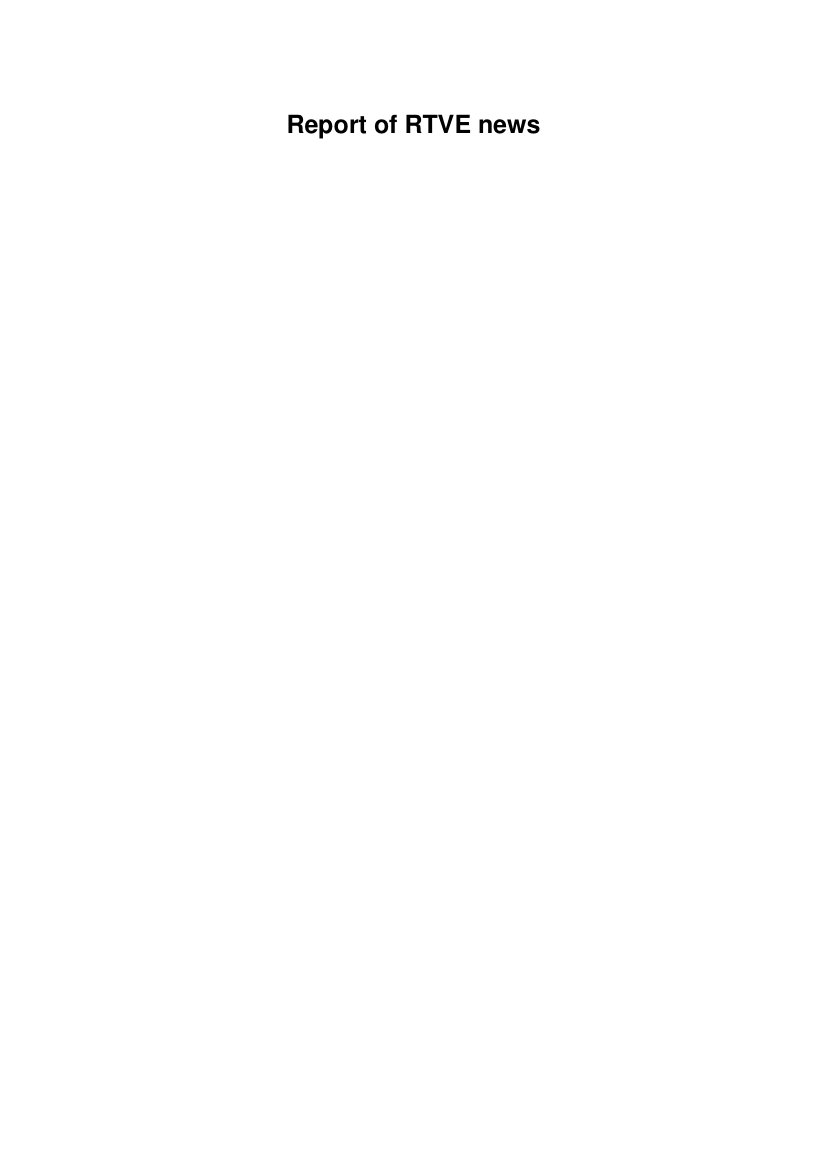

In [29]:
# Renders page 0 (the cover) to a PNG and displays it inline.


doc = pymupdf.open("report.pdf")
pix = doc[0].get_pixmap(dpi=100)
pix.save("report_preview.png")
Image("report_preview.png")


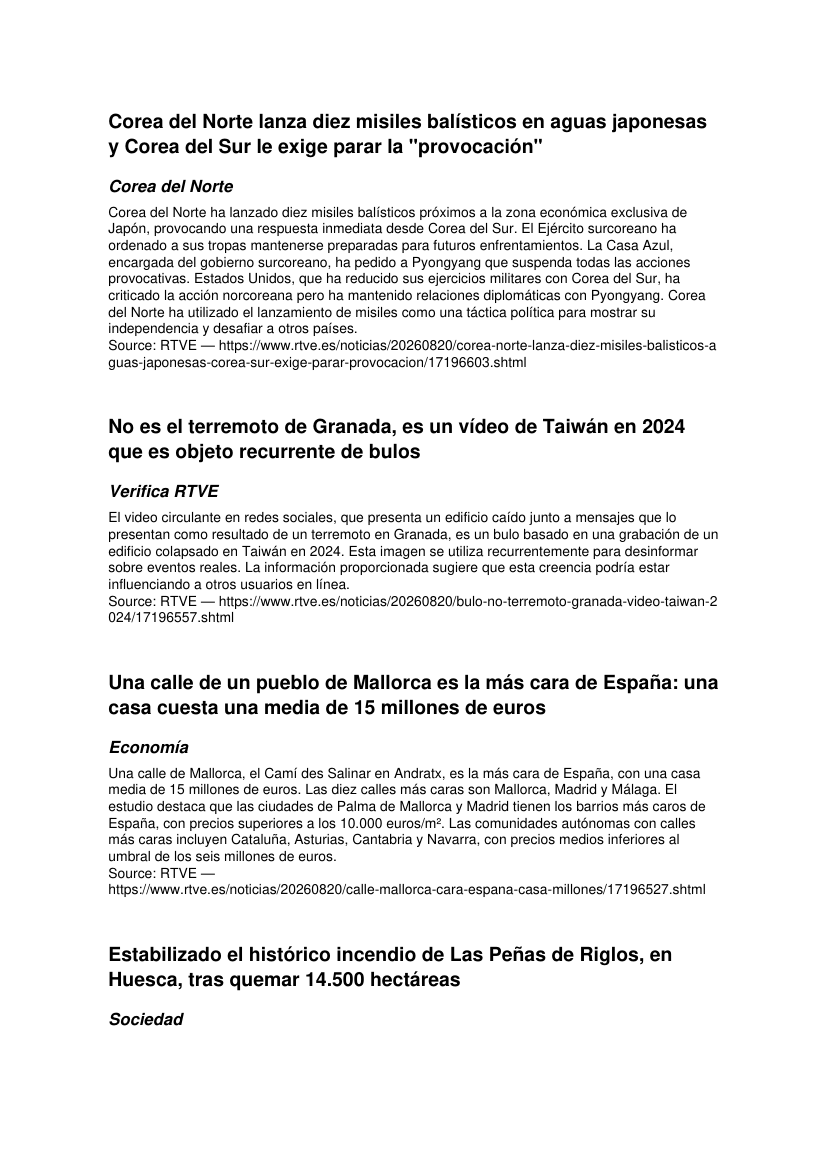

In [30]:
# Page 1: the first page with actual news items.
pix = doc[1].get_pixmap(dpi=100)
pix.save("report_preview.png")
Image("report_preview.png")


## Conclusions

This notebook turns RTVE's live Google News sitemap into a compact, source-linked PDF report, without assuming anything about the source that wasn't verified directly against the live site: the classic RSS feed's real status (stale, blocked by its own `robots.txt`), the sitemap's actual freshness behavior (not limited to 48h as typically expected, mixing entries from 2008 through today), the exact HTML selectors for the article body/description/category, and RTVE's own bot-management layer (served via an `/akamai/` path) all came from checking the live site, not from documentation.

The most significant design decision wasn't a modeling choice but a compliance one: the full scraped article text is never published anywhere downstream, only stored internally to build the AI-generated summary. What's public, per article, is title, category, summary, and a citation (source + link) built in plain code from the database, never left for the model to generate from memory.

This notebook is the exploratory version of the pipeline. The same logic, without Prefect and re-verified end to end, runs as a standalone script (`automated_news_report.py`) orchestrated with Prefect, containerized with Docker, and deployed as a real interactive dashboard — see the main [README](README.md) for the full write-up, including why the deployment ended up self-hosted instead of on the originally planned cloud platform.
